In [142]:
# --- IMPORT STATEMENTS ---

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from reproject import reproject_interp
import healpy as hp

In [143]:
# --- GLOBAL VARIABLES ---

SAVE_FIGS = False

LINUX_DIRECTORY = "/home/aimee/mphys" # Aimee
FIGURE_SAVEDIR = "figures" # Aimee
MAPS_DIR = f'{LINUX_DIRECTORY}/data/3D_wcs_maps' # Aimee
MAPS_SAVEDIR = f'{LINUX_DIRECTORY}/data/maps'

EFFELSBERG_MAPS = { # name : [file name, frequency / Hz]
    "Effelsberg 2.73 GHz" : ['Effelsberg_2.7272GHz_raw.fits'] # raw from website - 3D WCS (code can't handle it)
    # "Effelsberg 2.73 GHz" : ["EFFELSBERG-2.7272727272727275GHz-5.0amin.fits"] # TJ Rennie's pre-processed map (not ideal, but WCS works)
}

NOBEYAMA_MAPS = { # name : [file name, frequency / Hz]
   "Nobeyama 10 GHz" : ["Nobeyama_10.0GHz_raw.fits"] # raw from website - 3D WCS (code can't handle it)
    # "Nobeyama 10 GHz" : ["NOBEYAMA-10.0GHz-5.0amin.fits"] # TJ Rennie's pre-processed map (not ideal, but WCS works)
}

PARKES_MAPS = { # name : [file name, frequency / Hz]
    "Parkes 5 GHz" : ["Parkes_5.0GHz_raw.fits"] # raw from website - 3D WCS (code can't handle it)
    # "Parkes 5 GHz" : ["PARKES-5.0GHz-5.0amin.fits"] # CORRUPTED
}

In [144]:
# --- FUNCTION DEFINTIONS ---

def get_map(path):
    
    print(f"Getting data from {path}")
    fits_file = fits.open(path)

    data = fits_file[0].data
    header = fits_file[0].header
    wcs = WCS(header)
        
    return data, header, wcs

In [145]:
def plot_fits(fits_data, projection, x_coords=[], y_coords=[], title='Title', save_figs=SAVE_FIGS):
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = 0 #np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        ax.plot(x_coords, y_coords, 'rx', markersize=3)
    
    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [mK]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if save_figs:
        plt.savefig(f"{LINUX_DIRECTORY}/{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

In [146]:
def make_2d(data, header, wcs):

    # print(f'\nOLD WCS/HEADER:')
    # print(wcs)
    # print(header)

    data = data[0, :, :]

    new_wcs = WCS(header).celestial # Use only celestial part of WCS (if it's a multi-dimensional WCS)
    new_wcs.wcs.ctype = ['GLON-CAR', 'GLAT-CAR'] 

    new_wcs.wcs.crpix[0] = wcs.wcs.crpix[0]
    new_wcs.wcs.crpix[1] = wcs.wcs.crpix[1]
    new_wcs.wcs.cdelt[0] = wcs.wcs.cdelt[0]
    new_wcs.wcs.cdelt[1] = wcs.wcs.cdelt[1]
    new_wcs.wcs.crval[0] = wcs.wcs.crval[0]
    new_wcs.wcs.crval[1] = wcs.wcs.crval[1]

    new_header = new_wcs.to_header()

    # print('\nNEW WCS/HEADER:')
    # print(new_wcs)
    # print(header_new)

    return data, new_header, new_wcs

In [147]:
def save_fits(data, header, savepath):
    hdu = fits.PrimaryHDU(data=data, header=header)
    # hdu.header['BUNIT'] = 'Jy/sr'
    hdu.header['NAXIS1'] = data.shape[1]
    hdu.header['NAXIS2'] = data.shape[0]

    hdu.writeto(savepath, overwrite=True)
    print(f'Map saved to {savepath}')

In [148]:
# can use reproject for oversampling - fluxes will not be correct but once rebin and average in maps_processing.ipynb (T-T plots etc), will be correct

def reproject_data(data, wcs, target_wcs):
    
    # print(wcs)
    # print(target_wcs)
    factor = wcs.wcs.cdelt[0] / target_wcs.wcs.cdelt[0]
    # print(factor)
    shape = data.shape
    # print(shape)

    # Compute new shape in pixels for the same area with 1 arcmin/pixel
    new_shape = (int(np.ceil(shape[0] * factor)), int(np.ceil(shape[1] * factor)))  # Ensure integer values
    # print(new_shape)

    # Reproject the mosaic to the new WCS
    data_reprojected, footprint = reproject_interp(
        (data, wcs),
        target_wcs,
        shape_out=new_shape
    )
    
    return data_reprojected


In [149]:
def align_grids(header, target_header):
    
    # Find pixel offset at origin for map
    wcs = WCS(header)
    origin_coords = wcs.all_pix2world(0, 0, 0)
    print(origin_coords)
    x_offset = origin_coords[0] - np.floor(origin_coords[0])
    y_offset = origin_coords[1] - np.floor(origin_coords[1])
    print(x_offset, y_offset)
    
    # Find pixel offset at origin for target map (COMAP)
    target_wcs = WCS(target_header)
    target_origin_coords = target_wcs.all_pix2world(0, 0, 0)
    print(target_origin_coords)
    target_x_offset = target_origin_coords[0] - np.floor(target_origin_coords[0])
    target_y_offset = target_origin_coords[1] - np.floor(target_origin_coords[1])

    # Apply offset to crpix and crval - same as original map, but adjusted slightly to fit COMAP grid
    x_diff = target_x_offset - x_offset
    y_diff = target_y_offset - y_offset

    crpix1 = header['CRPIX1'] + x_diff
    crpix2 = header['CRPIX2'] + y_diff
    
    # crval1, crval2 = wcs.all_pix2world(crpix1, crpix2, 0)
    # less than 1 pixel difference -> << 1 degree difference -> crvals shouldn't change
    crval1 = header['CRVAL1'] 
    crval2 = header['CRVAL2']

    # Update target header with values on COMAP grid
    target_header['CRPIX1'] = crpix1
    target_header['CRPIX2'] = crpix2
    target_header['CRVAL1'] = int(crval1)
    target_header['CRVAL2'] = int(crval2)

    return target_header

# # TESTING
# _, comap_header, comap_wcs = get_map(f'{LINUX_DIRECTORY}/data/maps/comap_alr-2_galactic_301025_band00_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits')

# # print('\nCOMAP HEADER')
# # for key, value in comap_header.items():
# #     print(f'{key}, {value}')

# target_header = comap_header.copy()
# target_header['CDELT1'] = comap_header['CDELT1'] / 2 # 1/2 arcmin
# target_header['CDELT2'] = comap_header['CDELT2'] / 2 # 1/2 arcmin

# print('\nTARGET HEADER')
# for key, value in target_header.items():
#     print(f'{key}, {value}')

# data, header, wcs = get_map(f'{MAPS_DIR}/Parkes_5.0GHz_raw.fits')
# _, header, _ = make_2d(data, header, wcs)

# print('\nPARKES HEADER')
# for key, value in header.items():
#     print(f'{key}, {value}')

# target_header = align_grids(header, target_header)

# print('\nNEW TARGET HEADER')
# for key, value in target_header.items():
#     print(f'{key}, {value}')


Getting data from /home/aimee/mphys/data/maps/comap_alr-2_galactic_301025_band00_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits
Getting data from /home/aimee/mphys/data/3D_wcs_maps/Parkes_5.0GHz_raw.fits


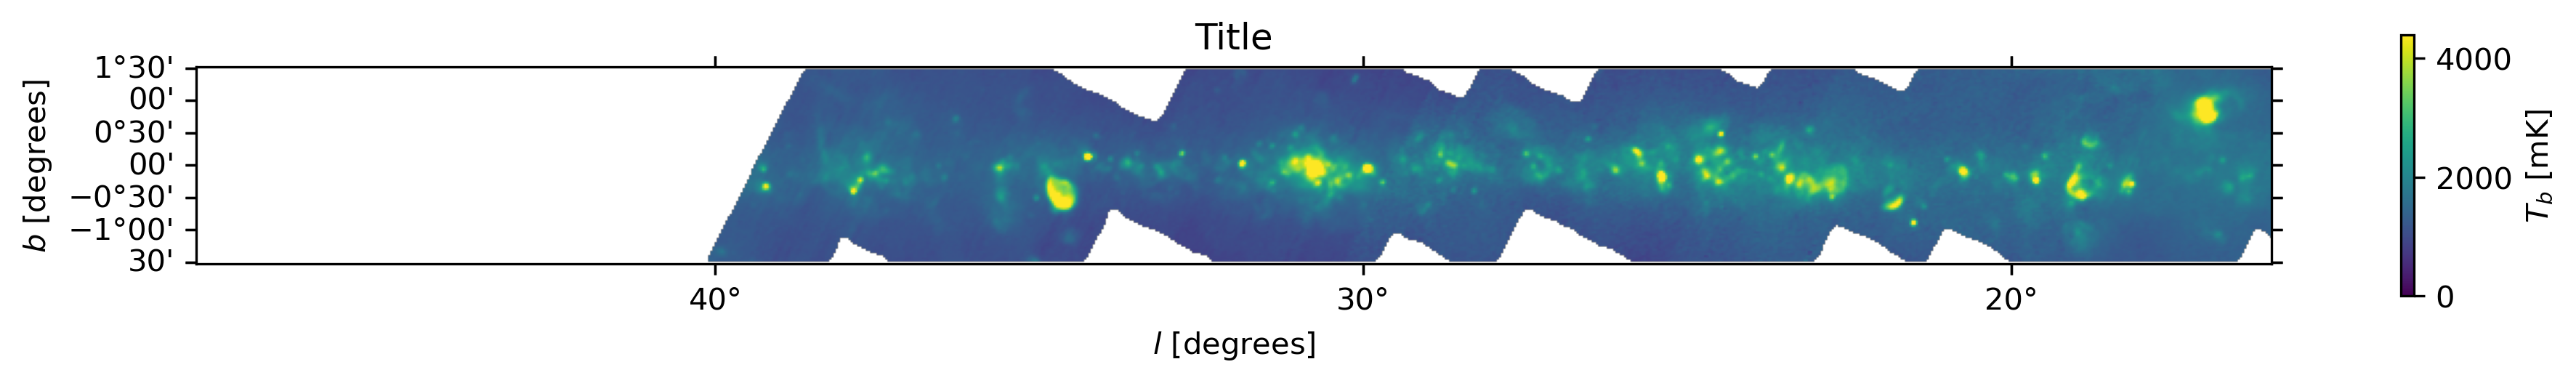


PARKES HEADER
WCSAXES, 2
CRPIX1, 481.0
CRPIX2, 46.0
CDELT1, -0.0333333333333
CDELT2, 0.0333333333333
CUNIT1, deg
CUNIT2, deg
CTYPE1, GLON-CAR
CTYPE2, GLAT-CAR
CRVAL1, 32.0
CRVAL2, 0.0
LONPOLE, 0.0
LATPOLE, 90.0
MJDREF, 0.0

TARGET HEADER - COMAP w/ 1/2 arcmin cdelt
SIMPLE, True
BITPIX, -32
NAXIS, 2
NAXIS1, 10801
NAXIS2, 601
EXTEND, True
WCSAXES, 2
CRPIX1, 5401.0
CRPIX2, 301.0
CDELT1, -0.0083333
CDELT2, 0.0083333
CUNIT1, deg
CUNIT2, deg
CTYPE1, GLON-CAR
CTYPE2, GLAT-CAR
CRVAL1, 90.0
CRVAL2, 0.0
LONPOLE, 0.0
LATPOLE, 90.0
MJDREF, 0.0
BUNIT, K_RJ
EXTNAME, PRIMARY
PIPE.NAME, COMAP Destriper
PIPE.VERS, 2024-11
PIPE.OFFLEN, 100
PIPE.HITPCT, 5.0
PIPE.HITMIN, 1
PIPE.EDGEW, 2
PIPE.CLIPLO, 0.5
PIPE.CLIPHI, 99.5
REG.PLANCKCUT, 0.045
REG.PLANCKDW, 0.1
DATA.BANDIDX, 0
DATAMIN, -0.5127140283584595
DATAMAX, 1.46775484085083
HISTORY, Destriped map = sky - offset_map
HISTORY, Masked low-hits below 5.0th percentile (>= 16.0)
HISTORY, Clipped border outliers using interior percentiles (0.5, 99.5)
[array

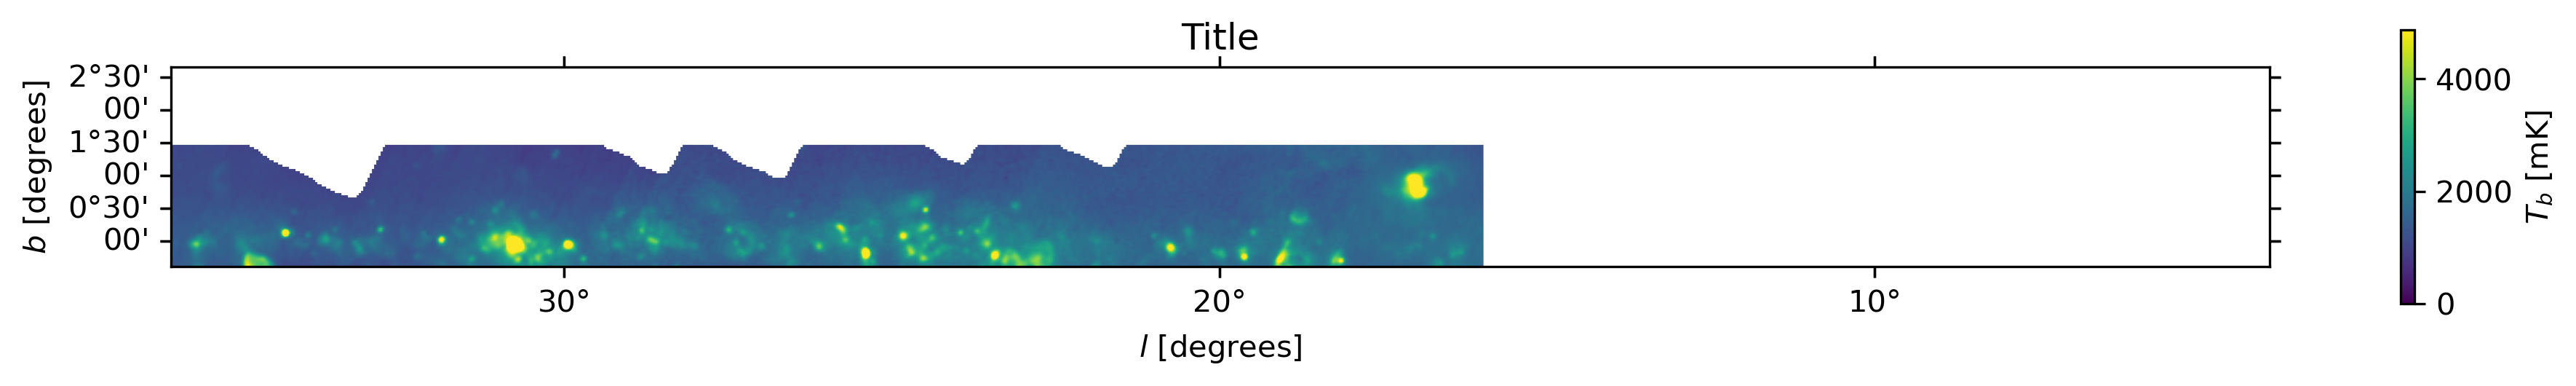

Getting data from /home/aimee/mphys/data/3D_wcs_maps/Effelsberg_2.7272GHz_raw.fits


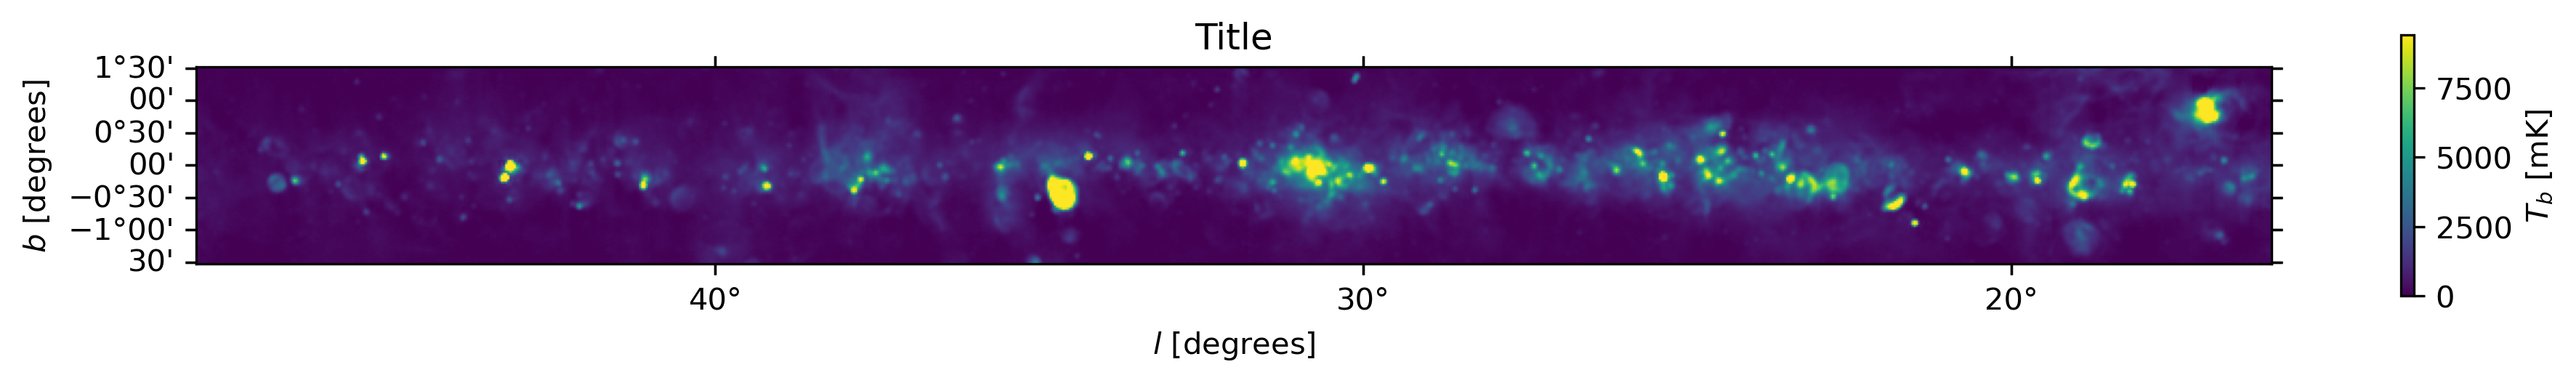


PARKES HEADER
WCSAXES, 2
CRPIX1, 481.0
CRPIX2, 46.0
CDELT1, -0.0333333333333
CDELT2, 0.0333333333333
CUNIT1, deg
CUNIT2, deg
CTYPE1, GLON-CAR
CTYPE2, GLAT-CAR
CRVAL1, 32.0
CRVAL2, 0.0
LONPOLE, 0.0
LATPOLE, 90.0
MJDREF, 0.0

TARGET HEADER - COMAP w/ 1/2 arcmin cdelt
SIMPLE, True
BITPIX, -32
NAXIS, 2
NAXIS1, 10801
NAXIS2, 601
EXTEND, True
WCSAXES, 2
CRPIX1, 5401.0
CRPIX2, 301.0
CDELT1, -0.0083333
CDELT2, 0.0083333
CUNIT1, deg
CUNIT2, deg
CTYPE1, GLON-CAR
CTYPE2, GLAT-CAR
CRVAL1, 90.0
CRVAL2, 0.0
LONPOLE, 0.0
LATPOLE, 90.0
MJDREF, 0.0
BUNIT, K_RJ
EXTNAME, PRIMARY
PIPE.NAME, COMAP Destriper
PIPE.VERS, 2024-11
PIPE.OFFLEN, 100
PIPE.HITPCT, 5.0
PIPE.HITMIN, 1
PIPE.EDGEW, 2
PIPE.CLIPLO, 0.5
PIPE.CLIPHI, 99.5
REG.PLANCKCUT, 0.045
REG.PLANCKDW, 0.1
DATA.BANDIDX, 0
DATAMIN, -0.5127140283584595
DATAMAX, 1.46775484085083
HISTORY, Destriped map = sky - offset_map
HISTORY, Masked low-hits below 5.0th percentile (>= 16.0)
HISTORY, Clipped border outliers using interior percentiles (0.5, 99.5)
[array

KeyboardInterrupt: 

In [150]:
# --- MAIN CODE --- 

map_names = [ # TO-DO: add Eff 1.3ish GHz (get from Bonn survey)
             "Parkes_5.0GHz_raw.fits", 
             'Effelsberg_2.7272GHz_raw.fits', 
             "Nobeyama_10.0GHz_raw.fits"
             ]

comap_data, comap_header, comap_wcs = get_map(f'{LINUX_DIRECTORY}/data/maps/comap_alr-2_galactic_301025_band00_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits')

# print('\nCOMAP HEADER')
# for key, value in comap_header.items():
#     print(f'{key}, {value}')


for map_name in map_names:
    # Get map data, make 2d
    map_path = f'{MAPS_DIR}/{map_name}'
    data, header, wcs = get_map(map_path)
    data, header, wcs = make_2d(data, header, wcs)
    plot_fits(data, wcs)
    # save_fits(data, header, savepath= f'{MAPS_SAVEDIR}/{map_name.replace(".fits", "")}_2d.fits')
    
    print('\nPARKES HEADER')
    for key, value in header.items():
        print(f'{key}, {value}')  

    # Create target header/wcs
    target_header = comap_header.copy()
    target_header['CDELT1'] = comap_header['CDELT1'] / 2
    target_header['CDELT2'] = comap_header['CDELT2'] / 2

    print('\nTARGET HEADER - COMAP w/ 1/2 arcmin cdelt')
    for key, value in target_header.items():
        print(f'{key}, {value}')  

    target_header = align_grids(header, target_header)

    print('\nTARGET HEADER - aligned grids')
    for key, value in target_header.items():
        print(f'{key}, {value}') 

    target_header['NAXIS1'] = int(data.shape[1] * 4)  # Adjust to match new resolution
    target_header['NAXIS2'] = int(data.shape[0] * 4)

    print('\nTARGET HEADER - correct shape')
    for key, value in target_header.items():
        print(f'{key}, {value}') 

    target_wcs = WCS(target_header)

    # print(wcs) # DEBUG
    data_reprojected, footprint = reproject_interp((data, wcs), target_wcs, 
                                                   shape_out=(target_header['NAXIS2'], target_header['NAXIS1']))
    # print("Reprojected data shape:", data_reprojected.shape)
    # print(f"Number of NaNs in reprojected data: {np.sum(np.isnan(data_reprojected))}")

    plot_fits(data_reprojected, target_wcs)
    # print(target_wcs) # DEBUG

    # save as new fits file
    # save_fits(data_reprojected, target_header, savepath= f'{MAPS_SAVEDIR}/{map_name.replace(".fits", "")}_1arcmin.fits')
